# 📊 Analyse Descriptive Multi-source (Gapminder + continents)
Ce notebook combine les données d'espérance de vie, de revenus et de continents pour produire des analyses détaillées.

In [8]:
#  Import des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import json
%matplotlib inline

In [9]:
#  Chargement des fichiers CSV + JSON
life_df = pd.read_csv('data_gapminder/life_expectancy_years.csv')
income_df = pd.read_csv('data_gapminder/income.csv')
with open('data_gapminder/country_continent.json') as f:
    country_continent = json.load(f)

In [10]:
#  Aperçu des datasets
display(life_df.head())
display(income_df.head())

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,Afghanistan,28.2,28.2,28.2,28.2,28.2,28.2,28.1,28.1,28.1,...,75.5,75.7,75.8,76.0,76.1,76.2,76.4,76.5,76.6,76.8
1,Angola,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,...,78.8,79.0,79.1,79.2,79.3,79.5,79.6,79.7,79.9,80.0
2,Albania,35.4,35.4,35.4,35.4,35.4,35.4,35.4,35.4,35.4,...,87.4,87.5,87.6,87.7,87.8,87.9,88.0,88.2,88.3,88.4
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,United Arab Emirates,30.7,30.7,30.7,30.7,30.7,30.7,30.7,30.7,30.7,...,82.4,82.5,82.6,82.7,82.8,82.9,83.0,83.1,83.2,83.3


,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,Afghanistan,683,683,683,683,683,683,683,683,683,...,2690,2750,2810,2870,2930,2990,3060,3120,3190,3260
1,Angola,700,702,705,709,711,714,718,721,725,...,8000,8170,8350,8530,8710,8900,9090,9280,9480,9690
2,Albania,755,755,755,755,755,756,756,756,756,...,25.1k,25.6k,26.2k,26.7k,27.3k,27.9k,28.5k,29.1k,29.7k,30.4k
3,Andorra,1360,1360,1360,1360,1370,1370,1370,1370,1380,...,68.9k,70.4k,71.9k,73.4k,75k,76.6k,78.3k,80k,81.7k,83.4k
4,United Arab Emirates,1130,1130,1140,1140,1150,1150,1160,1160,1160,...,101k,103k,105k,107k,110k,112k,114k,117k,119k,122k


In [11]:
# 🔄 Transformation des jeux de données (passage en long format)
life_long = life_df.melt(id_vars='country', var_name='year', value_name='life_expectancy')
income_long = income_df.melt(id_vars='country', var_name='year', value_name='income')

# 🔗 Fusion des deux jeux
merged_df = pd.merge(life_long, income_long, on=['country', 'year'])

In [12]:
# 🌍 Ajout des continents via le JSON
merged_df['continent'] = merged_df['country'].map(country_continent)
merged_df['year'] = merged_df['year'].astype(int)
merged_df.dropna(inplace=True)  # On supprime les lignes avec pays sans continent

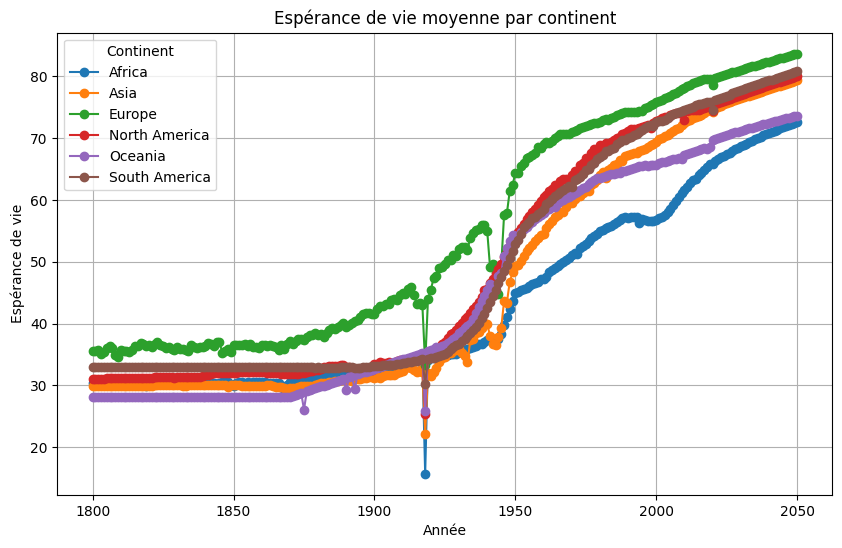

In [13]:
# 📈 Évolution de l'espérance de vie moyenne par continent
pivot_life = merged_df.groupby(['continent', 'year'])['life_expectancy'].mean().unstack(0)
pivot_life.plot(figsize=(10,6), marker='o')
plt.title("Espérance de vie moyenne par continent")
plt.ylabel("Espérance de vie")
plt.xlabel("Année")
plt.grid(True)
plt.legend(title='Continent')

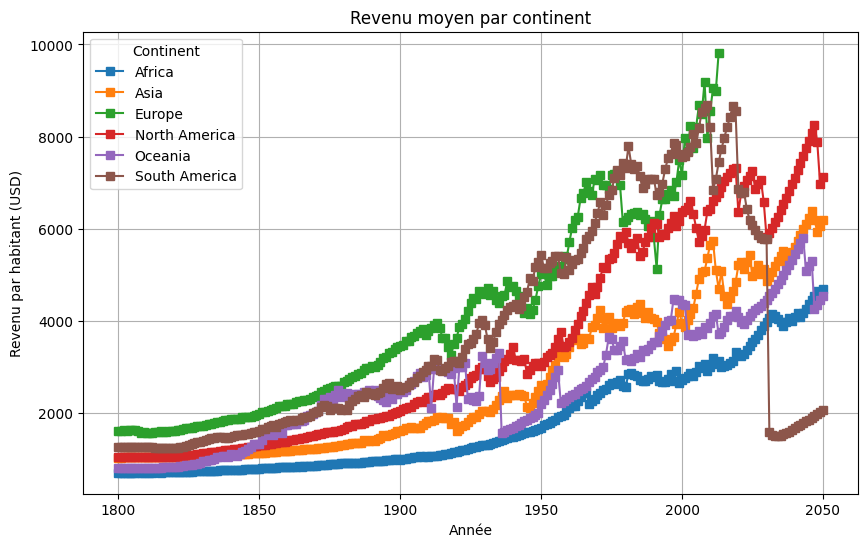

In [14]:
#  Évolution du revenu moyen par continent
merged_df['income'] = pd.to_numeric(merged_df['income'], errors='coerce')

pivot_income = merged_df.groupby(['continent', 'year'])['income'].mean().unstack(0)

pivot_income.plot(figsize=(10,6), marker='s')
plt.title("Revenu moyen par continent")
plt.ylabel("Revenu par habitant (USD)")
plt.xlabel("Année")
plt.grid(True)
plt.legend(title='Continent')


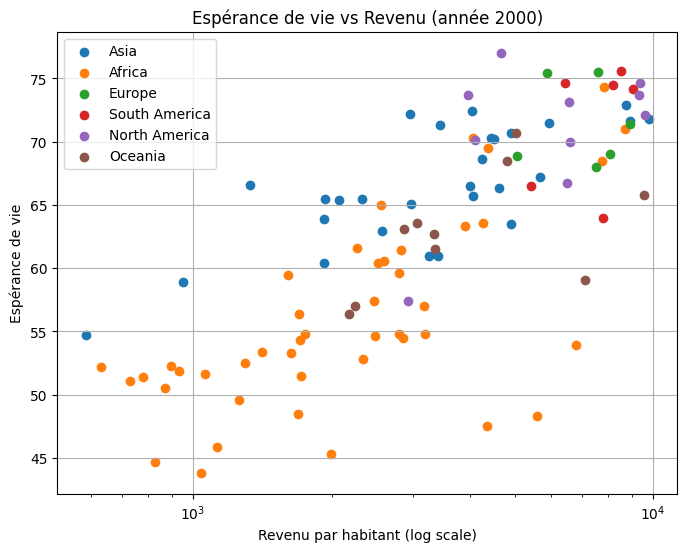

In [15]:
#  Corrélation entre espérance de vie et revenu (ex : année 2000)
df_2000 = merged_df[merged_df['year'] == 2000]
plt.figure(figsize=(8,6))
for cont in df_2000['continent'].unique():
    subset = df_2000[df_2000['continent'] == cont]
    plt.scatter(subset['income'], subset['life_expectancy'], label=cont)

plt.xscale('log')
plt.xlabel("Revenu par habitant (log scale)")
plt.ylabel("Espérance de vie")
plt.title("Espérance de vie vs Revenu (année 2000)")
plt.legend()
plt.grid(True)

In [16]:
#  Pays avec espérance de vie la plus haute et la plus basse chaque année
summary = merged_df.groupby('year').apply(lambda d: pd.Series({
    'Max LifeExp': d.loc[d['life_expectancy'].idxmax(), 'country'],
    'Min LifeExp': d.loc[d['life_expectancy'].idxmin(), 'country']
})).reset_index()
summary.head()

C:\Users\white\AppData\Local\Temp\ipykernel_28420\2769518141.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = merged_df.groupby('year').apply(lambda d: pd.Series({


,year,Max LifeExp,Min LifeExp
0,1800,Iceland,Yemen
1,1801,Finland,Yemen
2,1802,Denmark,Yemen
3,1803,Denmark,Iceland
4,1804,Denmark,Yemen
